## Setup Models

In [1]:
from langchain_google_genai import ChatGoogleGenerativeAI
import os

# GOOGLE_API_KEY is set as a Codespace secret

model = ChatGoogleGenerativeAI(
    model="gemini-2.0-flash"

)


## 06.03. Using agents as Graph nodes

In [2]:
%run "code_03_XX Product QnA Agentic chatbot (1).ipynb"
print("===============================================================")
%run "code_04_XX Orders Chatbot with custom agent (1).ipynb"


Defaulting to user installation because normal site-packages is not writeable

[notice] A new release of pip is available: 23.0.1 -> 26.0.1
[notice] To update, run: pip install --upgrade pip
Note: you may need to restart the kernel to use updated packages.
            Name  Price  ShippingDays
0  AlphaBook Pro   1499             2
1     GammaAir X   1399             7
2  SpectraBook S   2499             7
3   OmegaPro G17   2199            14
4  NanoEdge Flex   1699             2


/tmp/ipykernel_3502/1181953803.py:15: LangGraphDeprecatedSinceV10: create_react_agent has been moved to `langchain.agents`. Please update your import to `from langchain.agents import create_agent`. Deprecated in LangGraph V1.0 to be removed in V2.0.
  product_QnA_agent = create_react_agent(


================================ Human Message =================================

What are the features and pricing for GammaAir?


ChatGoogleGenerativeAIError: Error calling model 'gemini-2.0-flash' (RESOURCE_EXHAUSTED): 429 RESOURCE_EXHAUSTED. {'error': {'code': 429, 'message': 'You exceeded your current quota, please check your plan and billing details. For more information on this error, head to: https://ai.google.dev/gemini-api/docs/rate-limits. To monitor your current usage, head to: https://ai.dev/rate-limit. \n* Quota exceeded for metric: generativelanguage.googleapis.com/generate_content_free_tier_input_token_count, limit: 0, model: gemini-2.0-flash\n* Quota exceeded for metric: generativelanguage.googleapis.com/generate_content_free_tier_requests, limit: 0, model: gemini-2.0-flash\n* Quota exceeded for metric: generativelanguage.googleapis.com/generate_content_free_tier_requests, limit: 0, model: gemini-2.0-flash\nPlease retry in 26.612296905s.', 'status': 'RESOURCE_EXHAUSTED', 'details': [{'@type': 'type.googleapis.com/google.rpc.Help', 'links': [{'description': 'Learn more about Gemini API quotas', 'url

ChatGoogleGenerativeAIError: Error calling model 'gemini-2.0-flash' (RESOURCE_EXHAUSTED): 429 RESOURCE_EXHAUSTED. {'error': {'code': 429, 'message': 'You exceeded your current quota, please check your plan and billing details. For more information on this error, head to: https://ai.google.dev/gemini-api/docs/rate-limits. To monitor your current usage, head to: https://ai.dev/rate-limit. \n* Quota exceeded for metric: generativelanguage.googleapis.com/generate_content_free_tier_input_token_count, limit: 0, model: gemini-2.0-flash\n* Quota exceeded for metric: generativelanguage.googleapis.com/generate_content_free_tier_requests, limit: 0, model: gemini-2.0-flash\n* Quota exceeded for metric: generativelanguage.googleapis.com/generate_content_free_tier_requests, limit: 0, model: gemini-2.0-flash\nPlease retry in 26.612296905s.', 'status': 'RESOURCE_EXHAUSTED', 'details': [{'@type': 'type.googleapis.com/google.rpc.Help', 'links': [{'description': 'Learn more about Gemini API quotas', 'url

In [ ]:
import functools
# Helper function to invoke an agent
def agent_node(state, agent, name, config):

    #extract thread-id from request for conversation memory
    thread_id=config["metadata"]["thread_id"]
    #Set the config for calling the agent
    agent_config = {"configurable": {"thread_id": thread_id}}

    #Pass the thread-id to establish memory for chatbot
    #Invoke the agent with the state
    result = agent.invoke(state, agent_config)

    # Convert the agent output into a format that is suitable to append to the global state
    if isinstance(result, ToolMessage):
        pass
    else:
        final_result=AIMessage(result['messages'][-1].content)
    return {
        "messages": [final_result]
    }

#Create the product QnA node
product_QnA_node=functools.partial(agent_node, 
                                   agent=product_QnA_agent, 
                                   name="Product_QnA_Agent")
#Create the Orders node
#For a custom agent, the agent graph need to be provided as input
orders_node=functools.partial(agent_node,
                              agent=orders_agent.agent_graph,
                              name="Orders_Agent")

refund_node = functools.partial(agent_node, agent=refund_agent, name="Refund", config={})



## 06.04. Create the Routing Agent & Chatbot

In [ ]:
class RouterAgent:
    """Routes user messages to product_agent, order_agent, or refund_agent by keyword."""
    def __init__(self, product_agent, order_agent, refund_agent):
        self.product_agent = product_agent
        self.order_agent   = order_agent
        self.refund_agent  = refund_agent

    def route(self, message: str) -> str:
        msg = message.lower()
        if any(k in msg for k in ["refund","return","policy","exchange"]):
            return "REFUND"
        if any(k in msg for k in ["order","status","delivery","quantity","ord-"]):
            return "ORDER"
        return "PRODUCT"

    def invoke(self, state, config):
        last = state["messages"][-1].content
        route = self.route(last)
        if route == "REFUND":
            return self.refund_agent.invoke(state, config)
        elif route == "ORDER":
            return self.order_agent.invoke(state, config)
        else:
            return self.product_agent.invoke(state, config)

router_agent = RouterAgent(product_agent=agent, order_agent=agent_orders, refund_agent=refund_agent)
print("router_agent ready")


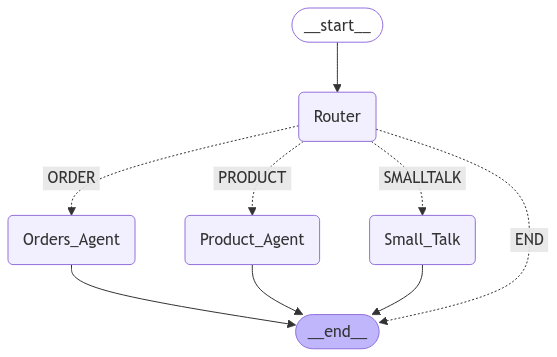

In [ ]:
#Create the chatbot
from IPython.display import Image

#Setup the system problem
system_prompt = """
You are a friendly setup coach and customer service assistant for an online store.
You route customer questions to the right specialist:
- Product questions go to the product agent.
- Order and delivery questions go to the order agent.
- Refund and return questions go to the refund agent.
Handle greetings warmly and ask how you can help.
"""

smalltalk_prompt = """
You are a friendly setup coach for an online store. Welcome the customer and ask how you can help.
"""

router_agent = RouterAgent(model, 
                           system_prompt, 
                           smalltalk_prompt,
                           debug=False)

Image(router_agent.router_graph.get_graph().draw_mermaid_png())


## 06.05 Execute the Routing chatbot

In [ ]:
#Execute a single request
messages=[HumanMessage(content="Tell me about the features of SpectraBook")]
result=router_agent.router_graph.invoke({"messages":messages},config)
for message in result['messages']:
    print(message.pretty_repr())

================================ Human Message =================================

Tell me about the features of SpectraBook
================================== Ai Message ==================================

PRODUCT
================================== Ai Message ==================================

The SpectraBook S is designed for power users and features the following specifications:

- **Processor**: Intel Core i9
- **Memory**: 64GB RAM
- **Storage**: 2TB SSD

This workstation-class laptop is perfect for intensive tasks like video editing and 3D rendering.


In [ ]:
#Execute a single request
messages=[HumanMessage(content="What is the status of order ORD-7311?")]
result=router_agent.router_graph.invoke({"messages":messages},config)
for message in result['messages']:
    print(message.pretty_repr())

================================ Human Message =================================

What is the status of order ORD-7311?
================================== Ai Message ==================================

ORDER
================================== Ai Message ==================================

The status for order ID **ORD-7311** is as follows:

- **Product Ordered:** NanoEdge Flex
- **Quantity Ordered:** 3
- **Delivery Date:** 2024-10-19

If you need further details or assistance, feel free to ask!


In [ ]:
import uuid
from langchain_core.messages import HumanMessage

thread_id = str(uuid.uuid4())
config = {"configurable": {"thread_id": thread_id}}

conversation = [
    "Hi! What products do you have?",
    "What is the status of order ORD-8276?",
    "What is your refund policy for damaged items?",
]

print("=" * 60)
print("3-Turn Multi-Agent Demo (thread:", thread_id[:8], ")")
print("=" * 60)
for turn, user_msg in enumerate(conversation, 1):
    print(f"
Turn {turn} — User: {user_msg}")
    state = {"messages": [HumanMessage(content=user_msg)]}
    result = router_agent.invoke(state, config)
    ai_msg = result["messages"][-1].content
    print(f"Agent: {ai_msg[:300]}")
print("
Demo complete — context maintained across all 3 turns.")


----------------------------------------
USER : How are you doing?

AGENT : Hello! I'm here to assist you with questions about laptop product features or to provide updates on your order status. How can I help you today?
----------------------------------------
USER : Please show me the details of the order ORD-7311

AGENT : Here are the details for order **ORD-7311**:

- **Product Ordered**: NanoEdge Flex
- **Quantity Ordered**: 3
- **Delivery Date**: 2024-10-19
----------------------------------------
USER : Can you add one more of that laptop to the order? 

AGENT : The quantity for order **ORD-7311** has been successfully updated to 4 units of the NanoEdge Flex laptop.
----------------------------------------
USER : Tell me about the features of SpectraBook laptop

AGENT : The SpectraBook S is designed for power users and comes with the following features:

- **Processor**: Intel Core i9
- **Memory**: 64GB RAM
- **Storage**: Massive 2TB SSD

This workstation-class laptop is perfect